In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [3]:
df = pd.read_csv('/content/drive/MyDrive/house_price_prediction/01_dataset/houses.txt', header=None)
df.head()

,0,1,2,3,4
0,952.0,2.0,1.0,65.0,271.5
1,1244.0,3.0,1.0,64.0,300.0
2,1947.0,3.0,2.0,17.0,509.8
3,1725.0,3.0,2.0,42.0,394.0
4,1959.0,3.0,2.0,15.0,540.0


In [4]:
df.shape

(100, 5)

In [5]:
X_train = df.iloc[: , :4].values
y_train = df.iloc[: , -1].values


In [6]:
X_train[:10]

array([[9.520e+02, 2.000e+00, 1.000e+00, 6.500e+01],
       [1.244e+03, 3.000e+00, 1.000e+00, 6.400e+01],
       [1.947e+03, 3.000e+00, 2.000e+00, 1.700e+01],
       [1.725e+03, 3.000e+00, 2.000e+00, 4.200e+01],
       [1.959e+03, 3.000e+00, 2.000e+00, 1.500e+01],
       [1.314e+03, 2.000e+00, 1.000e+00, 1.400e+01],
       [8.640e+02, 2.000e+00, 1.000e+00, 6.600e+01],
       [1.836e+03, 3.000e+00, 1.000e+00, 1.700e+01],
       [1.026e+03, 3.000e+00, 1.000e+00, 4.300e+01],
       [3.194e+03, 4.000e+00, 2.000e+00, 8.700e+01]])

In [7]:
y_train[:10]

array([271.5, 300. , 509.8, 394. , 540. , 415. , 230. , 560. , 294. ,
       718.2])

In [8]:
X_features = ['size(sqft)', 'bedrooms', 'floors', 'age']
y_feature = "Price"


In [9]:
print(X_train.shape)
print(y_train.shape)

print(X_train[:10])
print(y_train[:10])

(100, 4)
(100,)
[[9.520e+02 2.000e+00 1.000e+00 6.500e+01]
 [1.244e+03 3.000e+00 1.000e+00 6.400e+01]
 [1.947e+03 3.000e+00 2.000e+00 1.700e+01]
 [1.725e+03 3.000e+00 2.000e+00 4.200e+01]
 [1.959e+03 3.000e+00 2.000e+00 1.500e+01]
 [1.314e+03 2.000e+00 1.000e+00 1.400e+01]
 [8.640e+02 2.000e+00 1.000e+00 6.600e+01]
 [1.836e+03 3.000e+00 1.000e+00 1.700e+01]
 [1.026e+03 3.000e+00 1.000e+00 4.300e+01]
 [3.194e+03 4.000e+00 2.000e+00 8.700e+01]]
[271.5 300.  509.8 394.  540.  415.  230.  560.  294.  718.2]


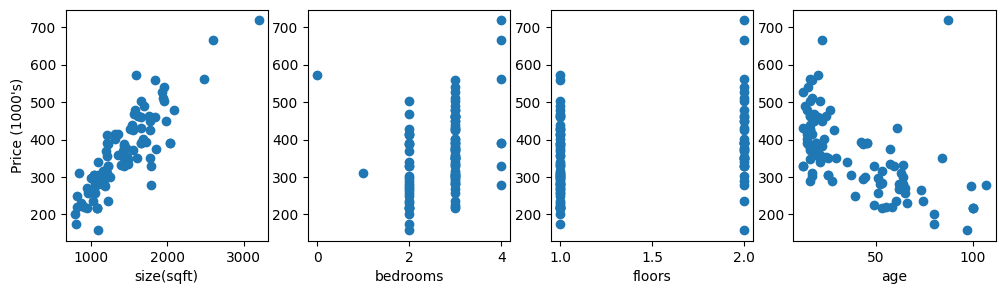

In [10]:
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
  ax[i].scatter(X_train[: , i], y_train)
  ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()


In [11]:
m,n = X_train.shape
w_in = [0.1 , 1, 0.01, 0.2]
b_in = 10
print(m)
print(n)

100
4


In [12]:
def compute_cost(x,y,w,b):
  m,_ = x.shape
  cost = 0
  for i in range(m):
    f_wb_i = np.dot(x[i] , w) + b
    j_wb = (f_wb_i - y[i]) ** 2
    cost += j_wb
  cost = cost / (2* m)
  return cost

In [13]:
computed_cost = compute_cost(X_train, y_train, w_in, b_in)
print(computed_cost)

22933.18159824001


compute_gradient() → "Which direction should we move w and b?"

In [14]:
def compute_gradient(x,y,w,b):
  m = x.shape[0]
  dj_dw = 0
  dj_db = 0
  for i in range(m):
    f_wb_i = np.dot(w , x[i]) + b
    f_wb = f_wb_i - y[i]
    dj_dw_i = f_wb * x[i]
    dj_db_i = f_wb
    dj_dw += dj_dw_i
    dj_db += dj_db_i

  dj_dw = dj_dw / m
  dj_db = dj_db / m

  return dj_dw, dj_db

In [15]:
dj_dw_, dj_db_ = compute_gradient(X_train, y_train, w_in, b_in)
print(dj_dw_)
print(dj_db_)

[-3.03511252e+05 -5.47539680e+02 -2.81064220e+02 -6.35592518e+03]
-200.41471999999993


In [16]:
# Gradient Descent
def gradient_descent(x,y,w,b,alpha,iters,cost_fun, gradient_fun):
  cost_history = []

  for i in range(iters):
    dj_dw , dj_db = gradient_fun(x,y,w,b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    if i <10000:
      cost_history.append(cost_fun(x,y,w,b))

    if i % math.ceil(iters/10) == 0:
      print(f"Iteration: {i:4d} , Cost: {cost_history[-1]}")

  return w, b, cost_history

In [17]:
alpha_ = 9.9e-7
iterations = 10

In [18]:
w_f, b_f, hist = gradient_descent(X_train, y_train, w_in, b_in, alpha_, iterations, compute_cost, compute_gradient)
print(w_f)
print(b_f)
print(hist[:10])

Iteration:    0 , Cost: 29684.511306444332
Iteration:    1 , Cost: 38582.55226273913
Iteration:    2 , Cost: 50309.81072630032
Iteration:    3 , Cost: 65765.7830662505
Iteration:    4 , Cost: 86135.94371158363
Iteration:    5 , Cost: 112982.66653038835
Iteration:    6 , Cost: 148365.05296227912
Iteration:    7 , Cost: 194996.85726595588
Iteration:    8 , Cost: 256454.62114761007
Iteration:    9 , Cost: 337451.9809044113
[-0.31608262  0.99913938  0.009515    0.18125977]
9.999753924019709
[np.float64(29684.511306444332), np.float64(38582.55226273913), np.float64(50309.81072630032), np.float64(65765.7830662505), np.float64(86135.94371158363), np.float64(112982.66653038835), np.float64(148365.05296227912), np.float64(194996.85726595588), np.float64(256454.62114761007), np.float64(337451.9809044113)]


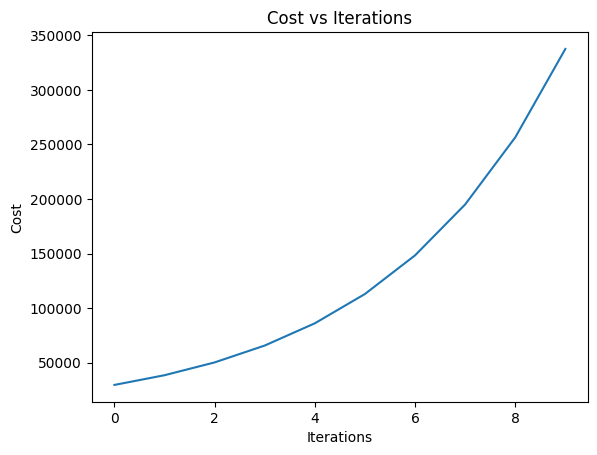

In [19]:
plt.plot(hist)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.show()

In [20]:
alpha_1 = 1e-7

In [21]:
w_f, b_f, hist = gradient_descent(X_train, y_train, w_in, b_in, alpha_1, iterations, compute_cost, compute_gradient)
print(w_f)
print(b_f)
print(hist[:10])

Iteration:    0 , Cost: 14716.984057033382
Iteration:    1 , Cost: 9679.318465617303
Iteration:    2 , Cost: 6590.520712510172
Iteration:    3 , Cost: 4696.641216691864
Iteration:    4 , Cost: 3535.4074230692313
Iteration:    5 , Cost: 2823.384045553897
Iteration:    6 , Cost: 2386.787110784098
Iteration:    7 , Cost: 2119.06365630299
Iteration:    8 , Cost: 1954.8823768770103
Iteration:    9 , Cost: 1854.1863905091523
[0.22777665 1.00022485 0.0101132  0.20215922]
10.00008583855913
[np.float64(14716.984057033382), np.float64(9679.318465617303), np.float64(6590.520712510172), np.float64(4696.641216691864), np.float64(3535.4074230692313), np.float64(2823.384045553897), np.float64(2386.787110784098), np.float64(2119.06365630299), np.float64(1954.8823768770103), np.float64(1854.1863905091523)]


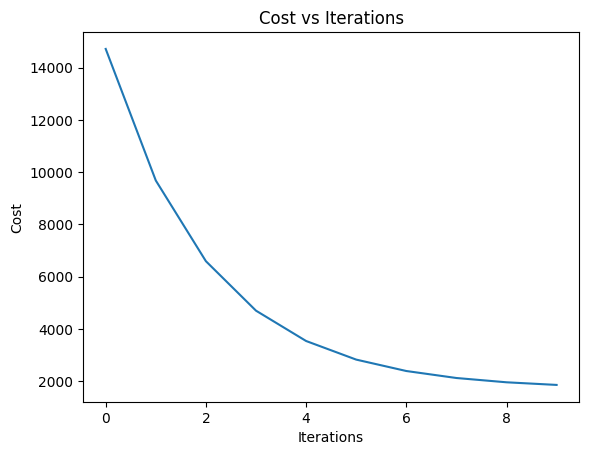

In [22]:
plt.plot(hist)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.show()

z score normalized function

In [23]:
X = np.array([10, 20, 30])

X.shape

(3,)

In [24]:
mu = np.mean(X, axis=0)
print(mu)

20.0


In [25]:
std_all = np.zeros(X.shape[0])
for i in range(X.shape[0]):
  std = mu - X[i]
  std_all[i] = std

In [26]:
print(std_all)

[ 10.   0. -10.]


In [27]:
std_all.shape

(3,)

In [28]:
mu.shape

()

In [29]:

X.shape

(3,)

In [30]:
avg = np.sum(X) / X.shape[0]
print(avg)

20.0


In [31]:
varience = np.zeros(X.shape[0])
for i in range(std_all.shape[0]):
  mu_sq = (std_all[i]) ** 2
  varience[i] = mu_sq

sum_all = 0
for j in range(varience.shape[0]):
  sum_ = 0 + varience[j]
  sum_all = sum_all + sum_
avg = sum_all/ (varience.shape[0])
print(varience)
print(avg)

std = avg ** 0.5
print(f"Standard Deviation: {std}")


[100.   0. 100.]
66.66666666666667
Standard Deviation: 8.16496580927726


In [32]:
X = np.array([
    [1000, 2, 1, 50],
    [1500, 3, 2, 30],
    [2000, 4, 1, 10]
])

In [33]:
X.shape

(3, 4)

In [34]:
mu = np.mean(X, axis=0)
print(mu)
print(type(mu))
print(mu.shape)

[1.50000000e+03 3.00000000e+00 1.33333333e+00 3.00000000e+01]
<class 'numpy.ndarray'>
(4,)


In [35]:
# mu is not the mean of entire training dataset. its an array having the mean for all the features.
# axis = 0 means perfrom opertion downward in the rows, seperte for each column. for example we have np.mean for X , where axis = 0 , means calculate the mean for each column seperatley.
# std() tells us that how spread out the values are around their mean.
def zscore_normalize_features(X):
  mu = np.mean(X, axis = 0)
  sigma = np.std(X, axis=0)
  X_norm = (X - mu) / sigma
  return mu, sigma, X_norm


In [36]:
print(X_train[:10])

[[9.520e+02 2.000e+00 1.000e+00 6.500e+01]
 [1.244e+03 3.000e+00 1.000e+00 6.400e+01]
 [1.947e+03 3.000e+00 2.000e+00 1.700e+01]
 [1.725e+03 3.000e+00 2.000e+00 4.200e+01]
 [1.959e+03 3.000e+00 2.000e+00 1.500e+01]
 [1.314e+03 2.000e+00 1.000e+00 1.400e+01]
 [8.640e+02 2.000e+00 1.000e+00 6.600e+01]
 [1.836e+03 3.000e+00 1.000e+00 1.700e+01]
 [1.026e+03 3.000e+00 1.000e+00 4.300e+01]
 [3.194e+03 4.000e+00 2.000e+00 8.700e+01]]


[1.41371e+03 2.71000e+00 1.38000e+00 3.86500e+01]
[412.17283499   0.65261014   0.48538644  25.78502472]


(np.float64(-1.8099446074028862),
 np.float64(4.611148136598506),
 np.float64(-1.2177610972457995),
 np.float64(2.834978860148661))

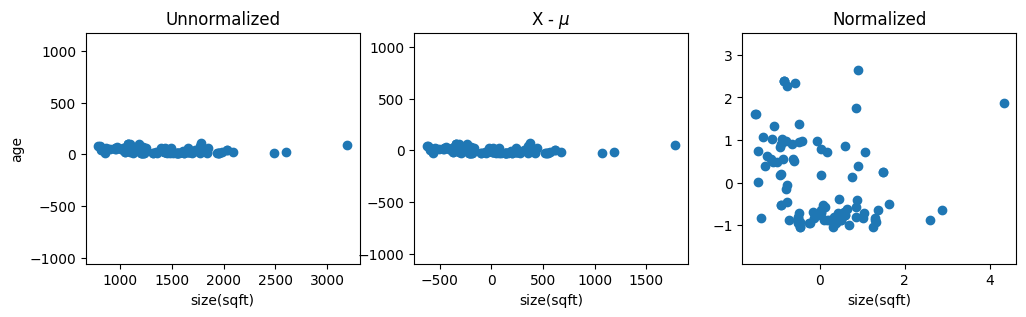

In [37]:
mu = np.mean(X_train, axis=0)
print(mu)
sigma = np.std(X_train, axis = 0)
print(sigma)
X_mean = X_train - mu
# print(X_mean[:10])
X_norm = X_mean / sigma
# print(X_norm[:10])

# X_mean = distance from the mean
# X_norm = distance from the mean measured in standard deviations

fig, ax = plt.subplots(1, 3 , figsize=(12, 3))
ax[0].scatter(X_train[: , 0], X_train[: , 3])
ax[0].set_xlabel(X_features[0])
ax[0].set_ylabel(X_features[3])
ax[0].set_title("Unnormalized")
ax[0].axis("equal")


ax[1].scatter(X_mean[:, 0] , X_mean[: , 3])
ax[1].set_xlabel(X_features[0])
ax[0].set_ylabel(X_features[3])
ax[1].set_title(r"X - $\mu$")
ax[1].axis("equal")


ax[2].scatter(X_norm[: , 0] , X_norm[: , 3])
ax[2].set_xlabel(X_features[0])
ax[0].set_ylabel(X_features[3])
ax[2].set_title("Normalized")
ax[2].axis("equal")

In [38]:
X_mu , X_sigma, X_norm = zscore_normalize_features(X_train)

print(f"X_mu: {X_mu}")
print(f"X_sigma: {X_sigma}")
# print(f"X_norm: {X_norm[:10]}")

print(f"Peak to Peak by column in original X_train: {np.ptp(X_train , axis= 0)}")
print(f"Peak to Peak by column in normalized X_train: {np.ptp(X_norm, axis = 0)}")

X_mu: [1.41371e+03 2.71000e+00 1.38000e+00 3.86500e+01]
X_sigma: [412.17283499   0.65261014   0.48538644  25.78502472]
Peak to Peak by column in original X_train: [2.406e+03 4.000e+00 1.000e+00 9.500e+01]
Peak to Peak by column in normalized X_train: [5.83735704 6.12923357 2.06021411 3.68430905]


In [61]:
def norm_plot(ax, x):
  ax.hist(x , bins = 20)
  ax.grid(True)

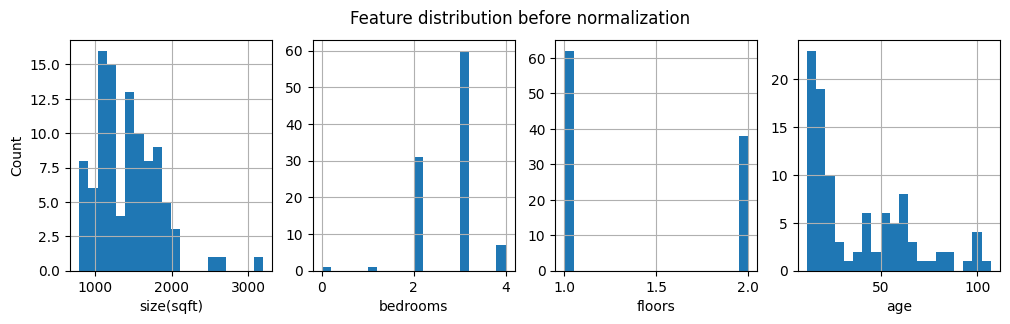

In [57]:
fig, ax = plt.subplots(1,4 , figsize=(12, 3))
for i in range(len(ax)):
  norm_plot(ax[i] , X_train[: , i])
  ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Count")
fig.suptitle("Feature distribution before normalization")
plt.show()

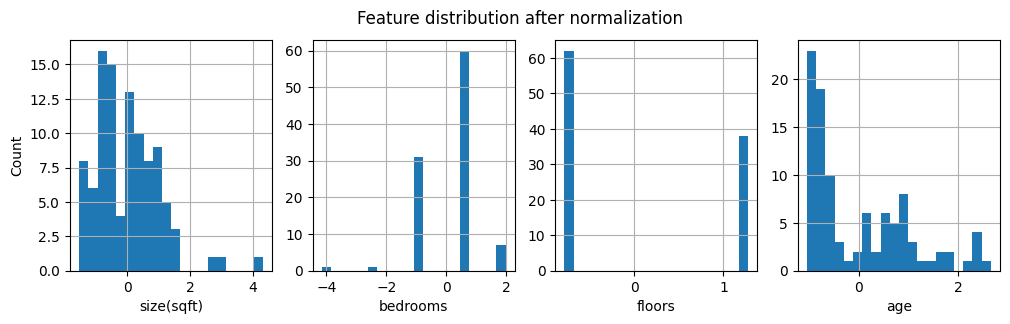

In [60]:
fig, ax = plt.subplots(1, 4 , figsize=(12, 3))
for i in range(len(ax)):
  norm_plot(ax[i] , X_norm[: , i])
  ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Count")
fig.suptitle("Feature distribution after normalization")
plt.show()

In [62]:
w_norm , b_norm , hist = gradient_descent(X_norm , y_train, w_in , b_in, 0.1 , 1000 , compute_cost, compute_gradient )
print(w_norm)
print(b_norm)
print(hist[:10])

Iteration:    0 , Cost: 54422.11361973622
Iteration:  100 , Cost: 221.73917246683735
Iteration:  200 , Cost: 219.71372282070843
Iteration:  300 , Cost: 219.7113046560314
Iteration:  400 , Cost: 219.71130176841427
Iteration:  500 , Cost: 219.71130176496624
Iteration:  600 , Cost: 219.71130176496186
Iteration:  700 , Cost: 219.71130176496197
Iteration:  800 , Cost: 219.71130176496214
Iteration:  900 , Cost: 219.71130176496186
[110.61335173 -21.47323884 -32.66070323 -37.77938362]
362.2395199999998
[np.float64(54422.11361973622), np.float64(44052.707112999466), np.float64(35749.50224492534), np.float64(29078.83125805717), np.float64(23705.335322811552), np.float64(19367.226939447162), np.float64(15858.551963773309), np.float64(13016.24928664589), np.float64(10710.555208297872), np.float64(8837.78089526902)]


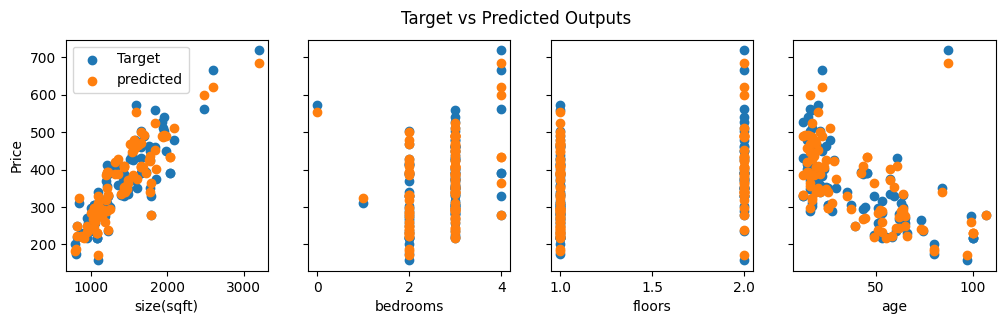

In [69]:
m = X_norm.shape[0]
yp = np.zeros(m)

for i in range(len(yp)):
  yp[i] = (np.dot(X_norm[i] , w_norm)) + b_norm

fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey= True)
for i in range(len(ax)):
  ax[i].scatter(X_train[: , i] , y_train, label = "Target")
  ax[i].scatter(X_train[: , i] , yp , label = "predicted")
  ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price")
ax[0].legend()
fig.suptitle("Target vs Predicted Outputs")
plt.show()

In [70]:
# Predicting on completely new data

x_house = np.array([1200, 3, 1, 40])
x_house_norm = (x_house - X_mu) / X_sigma
print(x_house_norm)

[-0.51849608  0.44436943 -0.78288136  0.05235597]


In [73]:
x_house_predict = np.dot(x_house , w_norm) + b_norm
print(x_house_predict * 1000)

131490005.83643976


In [74]:
x_house_predict = np.dot(x_house_norm , w_norm) + b_norm
print(x_house_predict * 1000)

318936.3590394069


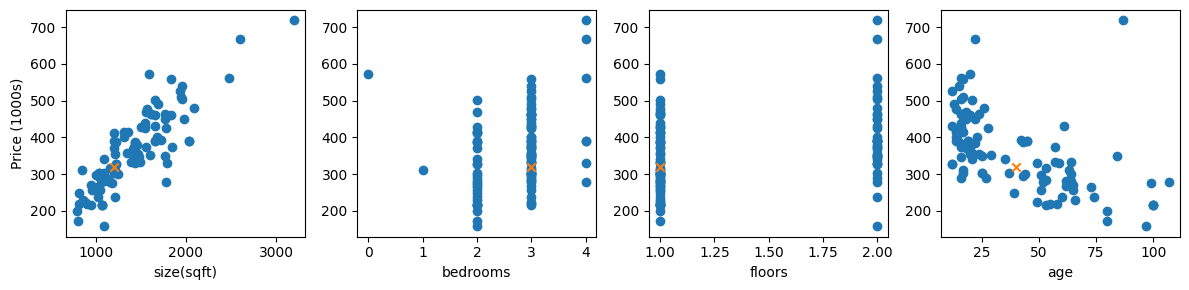

In [87]:
fig, ax = plt.subplots(1, 4 , figsize=(12, 3))
for i in range(4):
  ax[i].scatter(X_train[: , i], y_train, label = "Actual")
  ax[i].scatter(x_house[i] , x_house_predict, label= "New house" , marker = "x")
  ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000s)")
ax[0].legend=True

plt.tight_layout()
plt.show()
